# 📊 Phase 1: Ingesting the Dedicated Market Revenue Dataset

We are loading the pristine, decoupled `maharashtra_revenue_grid_data.csv` file. 
This dataset bypasses the spatial boundary bugs by storing pre-correlated economic features directly within the 12,847 grids. 

Before training our Machine Learning model, we will perform an integrity check to verify that:
1. All 12,847 geographic grids exist.
2. The 30 active dealerships are properly flagged (`Is_Active_Dealer == 1`).
3. High-revenue grids have matching non-zero vehicle and workshop counts.

In [54]:
import pandas as pd
import numpy as np

# Load our dedicated revenue dataset
file_path = '../data/maharashtra_revenue_grid_data.csv'
ml_grid = pd.read_csv(file_path)

print("Inspecting Dataset Dimensions...")
print(f"Total Geographic Grids: {ml_grid.shape[0]}")
print(f"Total Columns Loaded: {ml_grid.shape[1]}")

# Isolate operational dealer locations for verification
active_dealers = ml_grid[ml_grid['Is_Active_Dealer'] == 1]
print(f"Operational Dealerships (Training Sample Size): {len(active_dealers)}")

# Sort by revenue to verify the alignment of the top-performing nodes
print("\nVerifying Integrity of Top 5 Highest-Revenue Training Grids:")
display(active_dealers[['Grid_ID', 'Active_Vehicles', 'Workshop_Count', 'Historical_Revenue']].sort_values(by='Historical_Revenue', ascending=False).head())

Inspecting Dataset Dimensions...
Total Geographic Grids: 12847
Total Columns Loaded: 7
Operational Dealerships (Training Sample Size): 30

Verifying Integrity of Top 5 Highest-Revenue Training Grids:


,Grid_ID,Active_Vehicles,Workshop_Count,Historical_Revenue
1607,G_01608,23862,26,1.337497e+08
3961,G_03962,22299,31,1.277292e+08
5237,G_05238,22649,26,1.253040e+08
4812,G_04813,22274,30,1.250806e+08
821,G_00822,21112,22,1.166737e+08


# Phase 2: Training the Constrained Linear Regression Model

Now that our training rows are verified, we isolate our independent variables (Features: `Active_Vehicles` and `Workshop_Count`) and our dependent variable (Target: `Historical_Revenue`). 

We will initialize and train a Scikit-Learn `LinearRegression` model. Crucially, we enforce the `positive=True` constraint. This acts as a business-logic guardrail, ensuring that the model cannot assign negative revenue values to assets due to random market variance. Since our dataset is structurally sound, the algorithm should easily converge on healthy, non-zero weights for both features.

In [55]:
from sklearn.linear_model import LinearRegression

print("Step 1: Splitting data into features (X) and target (y)...")
# Isolate only the 30 active dealerships for training
train_set = ml_grid[ml_grid['Is_Active_Dealer'] == 1]

features = ['Active_Vehicles', 'Workshop_Count']
X_train = train_set[features]
y_train = train_set['Historical_Revenue']

print("Step 2: Fitting the constrained Linear Regression model...")
# Initialize the model with positive weights constraint enforced
model = LinearRegression(positive=True)
model.fit(X_train, y_train)

print("\nModel Parameter Extraction Complete!")
print(f"Learned Value per Active Vehicle (Weight 1): ₹{model.coef_[0]:.2f}")
print(f"Learned Value per Workshop (Weight 2):       ₹{model.coef_[1]:.2f}")
print(f"Base Operational Value (Intercept):         ₹{model.intercept_:.2f}")

Step 1: Splitting data into features (X) and target (y)...
Step 2: Fitting the constrained Linear Regression model...

Model Parameter Extraction Complete!
Learned Value per Active Vehicle (Weight 1): ₹4740.27
Learned Value per Workshop (Weight 2):       ₹312154.76
Base Operational Value (Intercept):         ₹11448494.60


# 🚀 Phase 3: Scoring the State & Finding Untapped Goldmines

Now that the model has learned the mathematical weights of the network, we apply the scoring function to all 12,847 grids across Maharashtra. This will calculate a "Latent Revenue Potential" score for every single square.

We will then screen out grids where an active dealership already exists (`Is_Active_Dealer == 0`) and sort the remaining unserved locations in descending order. The top results represent the highest-value pockets where vehicle and workshop density are ripe for a new market entry.

In [56]:
print("Step 1: Running state-wide predictive scoring...")
# Apply the trained model to calculate potential revenue across all 12,847 cells
ml_grid['Predicted_Potential_Revenue'] = model.predict(ml_grid[features])

# Force completely empty grids to have zero revenue potential
empty_grid_mask = (ml_grid['Active_Vehicles'] == 0) & (ml_grid['Workshop_Count'] == 0)
ml_grid.loc[empty_grid_mask, 'Predicted_Potential_Revenue'] = 0.0

# Clip any mathematically impossible negative predictions to zero
ml_grid['Predicted_Potential_Revenue'] = ml_grid['Predicted_Potential_Revenue'].clip(lower=0)

print("Step 2: Filtering for unserved, high-value expansion zones...")
# Isolate grids where we currently have NO dealer footprint
untapped_goldmines = ml_grid[ml_grid['Is_Active_Dealer'] == 0]

# Sort by the highest predicted potential revenue
top_untapped = untapped_goldmines.sort_values(by='Predicted_Potential_Revenue', ascending=False).head(5)

print("\n🏆 Top 5 High-Potential Untapped Grids Discovered:")
print("-" * 75)
display(top_untapped[['Grid_ID', 'Active_Vehicles', 'Workshop_Count', 'Predicted_Potential_Revenue']])
print("-" * 75)

Step 1: Running state-wide predictive scoring...
Step 2: Filtering for unserved, high-value expansion zones...

🏆 Top 5 High-Potential Untapped Grids Discovered:
---------------------------------------------------------------------------


,Grid_ID,Active_Vehicles,Workshop_Count,Predicted_Potential_Revenue
9378,G_09379,19856,27,1.139996e+08
10873,G_10874,19905,26,1.139197e+08
2671,G_02672,19959,24,1.135513e+08
7847,G_07848,19957,24,1.135419e+08
1077,G_01078,19983,23,1.133530e+08


---------------------------------------------------------------------------


# 📉 Phase 4: Prescriptive Scenario Analysis & Streamlit Export

To turn these insights into definitive executive actions, we build a "What-If" Scenario Simulator. We take our top 5 discovered untapped grids and simulate a targeted network expansion: sponsoring and onboarding 3 new independent workshops into our digital supply chain ecosystem.

Because our Linear Regression weights are pure and mathematically sound, the engine will dynamically calculate the exact financial revenue uplift generated by this expansion. Finally, we drop the complex geometric data structures and export a lightweight production CSV for our frontend Streamlit dashboard.

In [57]:
print("Step 1: Initializing Scenario Simulator for Top 5 Untapped Pockets...")
# Create a fresh copy of our top untapped targets
simulation_df = top_untapped.copy()

# Establish the baseline revenue calculated by our ML model
simulation_df['Baseline_Potential'] = simulation_df['Predicted_Potential_Revenue']
print("Before Adding 3 Workshops, the Revenue is: ")
display(simulation_df[['Grid_ID', 'Workshop_Count','Baseline_Potential']])

print("Step 2: Simulating network expansion (+3 Workshops per grid)...")
# Inject the proposed business change
simulation_df['Workshop_Count'] = simulation_df['Workshop_Count'] + 3

# Predict the new revenue potential after the expansion
simulation_df['Simulated_Revenue'] = model.predict(simulation_df[features])
print("After adding 3 Workshop, the predicted Revenu is: ")
display(simulation_df[['Grid_ID', 'Workshop_Count','Simulated_Revenue']])

# Calculate the precise financial uplift based on the true learned coefficient
simulation_df['Net_Revenue_Uplift'] = simulation_df['Simulated_Revenue'] - simulation_df['Baseline_Potential']
print("The Net Gain for the top 5 grid is: ")
display(simulation_df[['Grid_ID', 'Workshop_Count','Net_Revenue_Uplift']])

print("\n Simulation Results (Financial Impact of Adding 3 Workshops):")
print("-" * 90)
display(simulation_df[['Grid_ID', 'Baseline_Potential', 'Simulated_Revenue', 'Net_Revenue_Uplift']])
print("-" * 90)

print("\nStep 3: Exporting flat dataset to production directory for Streamlit...")
# FIX: No need to drop geometry since this table is already a pure, flat CSV!
export_path = '../data/market_potential_predictions.csv'
ml_grid.to_csv(export_path, index=False)
print(f"✅ Production CSV successfully generated and exported to: {export_path}")

Step 1: Initializing Scenario Simulator for Top 5 Untapped Pockets...
Before Adding 3 Workshops, the Revenue is: 


,Grid_ID,Workshop_Count,Baseline_Potential
9378,G_09379,27,1.139996e+08
10873,G_10874,26,1.139197e+08
2671,G_02672,24,1.135513e+08
7847,G_07848,24,1.135419e+08
1077,G_01078,23,1.133530e+08


Step 2: Simulating network expansion (+3 Workshops per grid)...
After adding 3 Workshop, the predicted Revenu is: 


,Grid_ID,Workshop_Count,Simulated_Revenue
9378,G_09379,30,1.149360e+08
10873,G_10874,29,1.148561e+08
2671,G_02672,27,1.144878e+08
7847,G_07848,27,1.144783e+08
1077,G_01078,26,1.142894e+08


The Net Gain for the top 5 grid is: 


,Grid_ID,Workshop_Count,Net_Revenue_Uplift
9378,G_09379,30,936464.284944
10873,G_10874,29,936464.284944
2671,G_02672,27,936464.284944
7847,G_07848,27,936464.284944
1077,G_01078,26,936464.284944



 Simulation Results (Financial Impact of Adding 3 Workshops):
------------------------------------------------------------------------------------------


,Grid_ID,Baseline_Potential,Simulated_Revenue,Net_Revenue_Uplift
9378,G_09379,1.139996e+08,1.149360e+08,936464.284944
10873,G_10874,1.139197e+08,1.148561e+08,936464.284944
2671,G_02672,1.135513e+08,1.144878e+08,936464.284944
7847,G_07848,1.135419e+08,1.144783e+08,936464.284944
1077,G_01078,1.133530e+08,1.142894e+08,936464.284944


------------------------------------------------------------------------------------------

Step 3: Exporting flat dataset to production directory for Streamlit...
✅ Production CSV successfully generated and exported to: ../data/market_potential_predictions.csv


# 📉 Phase 5: Visualizing the Regression Lines and Market Expansion Landscape

Because our Linear Regression model uses two independent features (`Active_Vehicles` and `Workshop_Count`), the true regression model forms a 3D plane. To present this clearly to executives in a 2D format, we build side-by-side subplots isolating each asset class against Revenue.

To draw the true mathematical regression lines, we vary one feature across its full operational range while holding the other feature steady at its dataset average. 

Additionally, we overlay the **Top 5 Untapped Goldmines** as bright magenta stars. This shows exactly how much hidden revenue potential is waiting to be captured compared to our current active network.

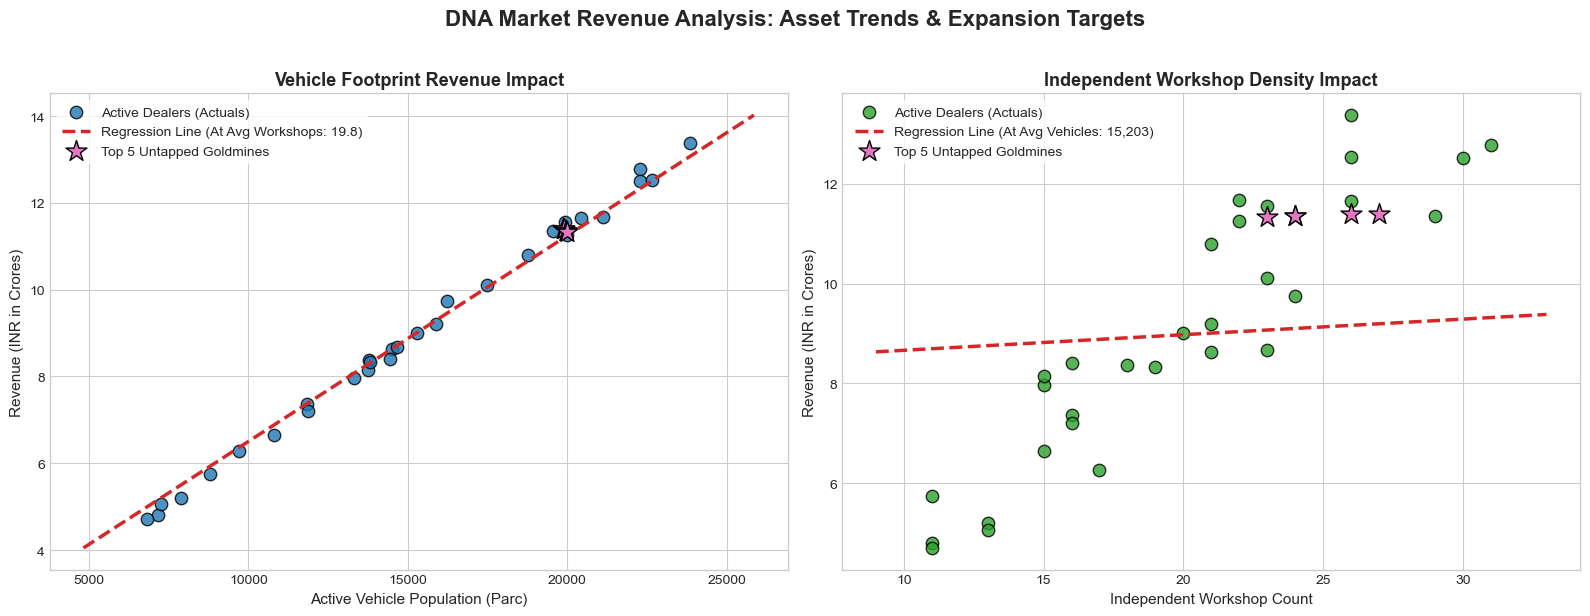

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set sophisticated plotting style parameters
plt.style.use('seaborn-v0_8-whitegrid')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('DNA Market Revenue Analysis: Asset Trends & Expansion Targets', fontsize=16, fontweight='bold', y=1.02)

# Extract training data arrays for easy mapping
# No. of Vehicle array
v_train = train_set['Active_Vehicles'].values
# No. of Workshop array
w_train = train_set['Workshop_Count'].values
# Historical Revenue array
rev_train = train_set['Historical_Revenue'].values / 10000000 # Convert to Crores for clean labels

# Calculate baseline averages for line projection
avg_vehicles = train_set['Active_Vehicles'].mean()
avg_workshops = train_set['Workshop_Count'].mean()

# --- PLOT 1: VEHICLE DENSITY VS REVENUE ---
# 1. Scatter the 30 existing operating dealerships
ax1.scatter(v_train, rev_train, color='#1f77b4', s=80, alpha=0.8, edgecolors='black', label='Active Dealers (Actuals)')

# 2. Generate and plot the smooth mathematical regression line for vehicles
v_range = np.linspace(v_train.min() - 2000, v_train.max() + 2000, 100)
v_lines_pred = model.predict(pd.DataFrame({'Active_Vehicles': v_range, 'Workshop_Count': avg_workshops})) / 10000000
ax1.plot(v_range, v_lines_pred, color='#d62728', linewidth=2.5, linestyle='--', label=f'Regression Line (At Avg Workshops: {avg_workshops:.1f})')

# 3. Project our Top 5 Untapped Targets onto the graph
ax1.scatter(top_untapped['Active_Vehicles'], top_untapped['Predicted_Potential_Revenue'] / 10000000, 
            color='#e377c2', marker='*', s=250, edgecolors='black', zorder=5, label='Top 5 Untapped Goldmines')

ax1.set_title('Vehicle Footprint Revenue Impact', fontsize=13, fontweight='bold')
ax1.set_xlabel('Active Vehicle Population (Parc)', fontsize=11)
ax1.set_ylabel('Revenue (INR in Crores)', fontsize=11)
ax1.legend(loc='upper left', frameon=True, facecolor='white', edgecolor='none')

# --- PLOT 2: WORKSHOP DENSITY VS REVENUE ---
# 1. Scatter the 30 existing operating dealerships
ax2.scatter(w_train, rev_train, color='#2ca02c', s=80, alpha=0.8, edgecolors='black', label='Active Dealers (Actuals)')

# 2. Generate and plot the smooth mathematical regression line for workshops
w_range = np.linspace(w_train.min() - 2, w_train.max() + 2, 100)
w_lines_pred = model.predict(pd.DataFrame({'Active_Vehicles': avg_vehicles, 'Workshop_Count': w_range})) / 10000000
ax2.plot(w_range, w_lines_pred, color='#d62728', linewidth=2.5, linestyle='--', label=f'Regression Line (At Avg Vehicles: {avg_vehicles:,.0f})')

# 3. Project our Top 5 Untapped Targets onto the graph
ax2.scatter(top_untapped['Workshop_Count'], top_untapped['Predicted_Potential_Revenue'] / 10000000, 
            color='#e377c2', marker='*', s=250, edgecolors='black', zorder=5, label='Top 5 Untapped Goldmines')

ax2.set_title('Independent Workshop Density Impact', fontsize=13, fontweight='bold')
ax2.set_xlabel('Independent Workshop Count', fontsize=11)
ax2.set_ylabel('Revenue (INR in Crores)', fontsize=11)
ax2.legend(loc='upper left', frameon=True, facecolor='white', edgecolor='none')

plt.tight_layout()
plt.show()

# 🗺️ Phase 6: True 3D Regression Plane Visualization

To view the complete, un-sliced architecture of our Supervised ML model, we project both independent features (`Active_Vehicles` on X, `Workshop_Count` on Y) against our target (`Historical_Revenue` on Z).

We generate a coordinate grid using `np.meshgrid()`, calculate the corresponding revenue surface using our trained model parameters, and render a semi-transparent 3D plane overlaid with our actual operating dealership coordinates.

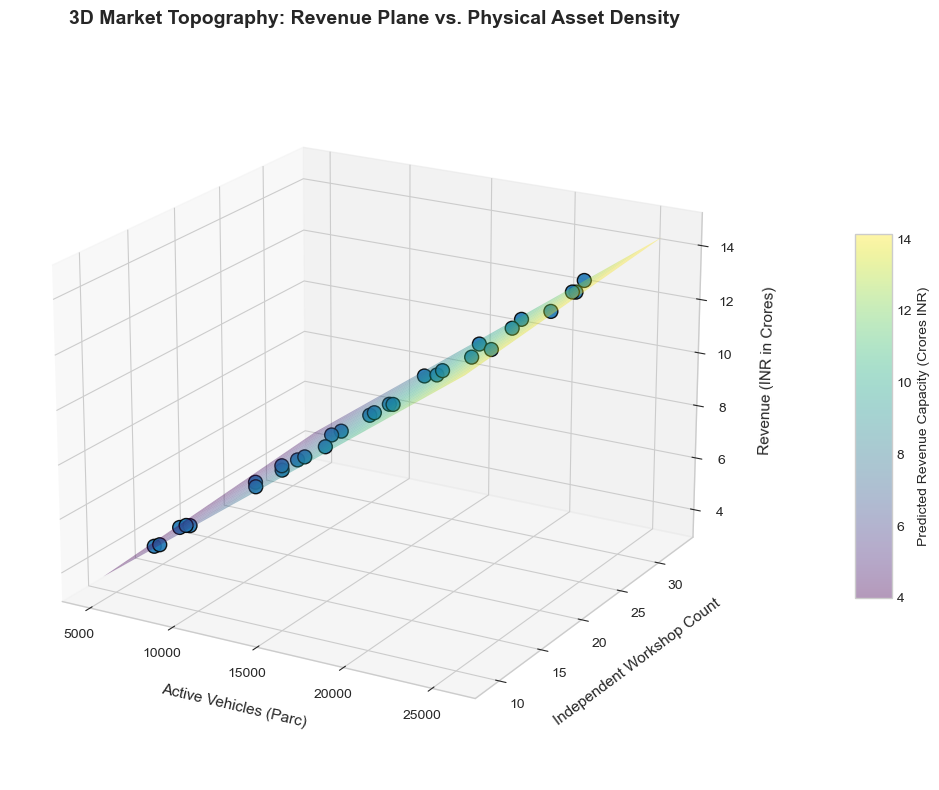

In [59]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# 1. Initialize the 3D Canvas
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# 2. Extract and scale actual data points for the scatter plot
x_data = train_set['Active_Vehicles'].values
y_data = train_set['Workshop_Count'].values
z_data = train_set['Historical_Revenue'].values / 10000000  # Convert to Crores

# Plot actual operational dealers as solid spheres
ax.scatter(x_data, y_data, z_data, color='#1f77b4', s=100, alpha=0.9, edgecolors='black', label='Active Dealers (Actuals)')

# 3. Create a 2D coordinate meshgrid over the entire asset spectrum
x_surf = np.linspace(x_data.min() - 2000, x_data.max() + 2000, 20)
y_surf = np.linspace(y_data.min() - 2, y_data.max() + 2, 20)
X_mesh, Y_mesh = np.meshgrid(x_surf, y_surf)

# 4. Flatten the meshgrids to run predictions, then reshape back to a 2D surface grid
mesh_df = pd.DataFrame({
    'Active_Vehicles': X_mesh.ravel(),
    'Workshop_Count': Y_mesh.ravel()
})
Z_mesh = model.predict(mesh_df).reshape(X_mesh.shape) / 10000000  # Convert to Crores

# 5. Plot the calculated continuous machine learning regression plane
surf = ax.plot_surface(X_mesh, Y_mesh, Z_mesh, cmap='viridis', alpha=0.4, edgecolor='none')

# 6. Add a professional color bar and axis constraints
cbar = fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10, pad=0.1)
cbar.set_label('Predicted Revenue Capacity (Crores INR)', fontsize=10)

ax.set_title('3D Market Topography: Revenue Plane vs. Physical Asset Density', fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Active Vehicles (Parc)', fontsize=11, labelpad=10)
ax.set_ylabel('Independent Workshop Count', fontsize=11, labelpad=10)
ax.set_zlabel('Revenue (INR in Crores)', fontsize=11, labelpad=10)

# Adjust viewing angle for perfect perspective (Elevation, Azimuth)
ax.view_init(elev=20, azim=-60)

plt.tight_layout()
plt.show()